# Data Analysis: Magnetic Fields in Coil Configurations

## Project Overview
This project investigates the spatial distribution of magnetic flux density $B(z)$ along the symmetry axis of various coil geometries. The analysis verifies the Biot-Savart law through experimental measurements of solenoids, flat circular coils, and Helmholtz coil pairs.

### Key Areas of Investigation:
1. **Solenoid Field Mapping**: Analyzing the uniformity of the magnetic field in long solenoids and the 50% drop-off at the boundaries.
2. **Circular Coil Dynamics**: Verifying the $z^{-3}$ field decay and determining effective coil radii.
3. **Superposition and Helmholtz Pairs**: Investigating field uniformity in the Helmholtz configuration ($b=R$) and other spacing variations.
4. **Numerical Fitting**: Applying robust data parsing and non-linear regression to experimental magnetic field data.

---

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, newton
from IPython.display import display, Markdown
import re

# --- Plotting Style ---
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'lines.linewidth': 2,
    'lines.markersize': 5,
    'figure.figsize': (10, 6),
    'errorbar.capsize': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

# --- Constants & Uncertainties ---
u_z = 0.2  # Uncertainty in position [cm]
u_B = 5.0  # Uncertainty in B-field [uT]

# --- Robust Data Parser ---
def parse_lab_data(filename):
    """
    Parses messy CSVs from Exp E07e.
    Extracts 'z' from headers like 'x=24.2 cm' and 'B' from cells like 'By = ...'
    """
    try:
        df = pd.read_csv(filename)
        data = []
        bg_val = 0.0

        # Check for background column (Task 1 specific)
        for col in df.columns:
            if 'background' in str(col).lower():
                val_str = str(df[col].dropna().iloc[0])
                m = re.search(r"By\s*=\s*([-\d\.]+)", val_str)
                if m: bg_val = float(m.group(1))

        # Extract Data
        for col in df.columns:
            col_str = str(col).strip()
            z = None

            # Regex for 'x=...' or just numbers
            m_x = re.search(r"x\s*=\s*([\d\.]+)", col_str)
            if m_x:
                z = float(m_x.group(1))
            else:
                try:
                    if "back" not in col_str.lower() and "unnamed" not in col_str.lower():
                        z = float(col_str)
                except: pass

            if z is not None:
                vals = df[col].dropna()
                if not vals.empty:
                    val_str = str(vals.iloc[0])
                    m_b = re.search(r"By\s*=\s*([-\d\.]+)", val_str)
                    if m_b:
                        data.append({'z': z, 'B': float(m_b.group(1))})

        df_clean = pd.DataFrame(data).sort_values('z').reset_index(drop=True)
        return df_clean, bg_val

    except Exception as e:
        print(f"Error parsing {filename}: {e}")
        return pd.DataFrame(), 0.0

# --- Helper to print Markdown Table in Output ---
def print_md_table(title, data_dict):
    df = pd.DataFrame(data_dict)
    display(Markdown(f"### {title}"))
    display(Markdown(df.to_markdown(index=False)))

print("Setup Complete.")

Setup Complete.


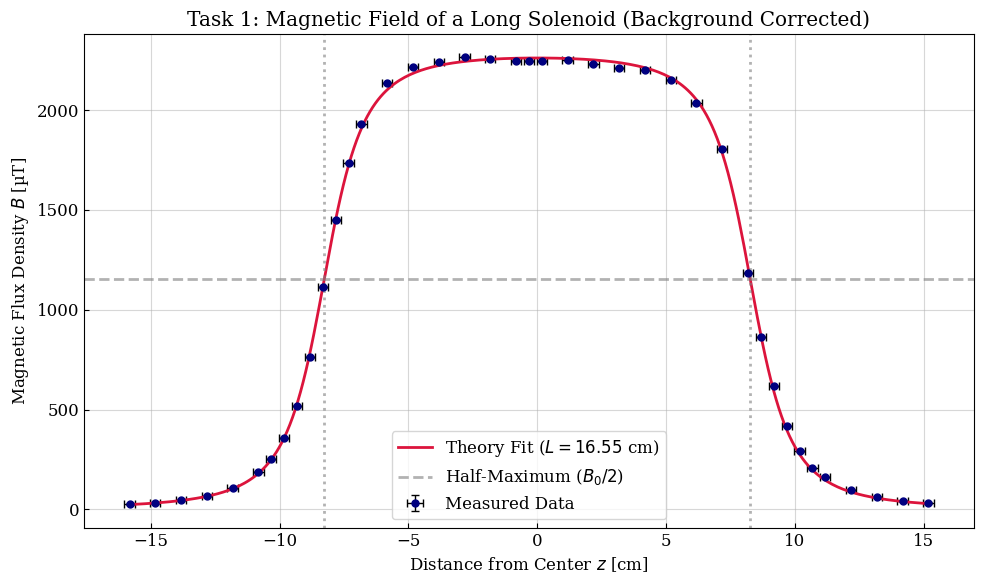

### Task 1 Results

| Parameter              | Value        | Unit   | Theoretical Expectation   |
|:-----------------------|:-------------|:-------|:--------------------------|
| Fitted Coil Length (L) | 16.55 ± 0.02 | cm     | ~16.1 (Label)             |
| Plateau Field (B0)     | 2305.6       | µT     | -                         |
| Field at End (z=L/2)   | 1147.2       | µT     | 1152.8                    |
| Ratio (Bend/B0)        | 0.498        | -      | 0.500                     |

In [9]:
# --- Load & Clean Data ---
df1, bg1 = parse_lab_data('e7task1.csv')
df1['B_corr'] = df1['B'] - bg1  # Background Subtraction

# --- Theory Model (Shifted) ---
def solenoid_shifted(z, B0, L, R, z0):
    zp = z - z0
    term1 = (L/2 + zp) / np.sqrt(R**2 + (L/2 + zp)**2)
    term2 = (L/2 - zp) / np.sqrt(R**2 + (L/2 - zp)**2)
    return (B0 / 2) * (term1 + term2)

# --- Fit ---
# Guesses: B0=2250, L=16.1 (from label), R=2.0, z0=25.0
popt1, pcov1 = curve_fit(solenoid_shifted, df1['z'], df1['B_corr'],
                         p0=[2250, 16.1, 2.0, 25.0])
B0_fit, L_fit, R_fit, z0_fit = popt1
perr1 = np.sqrt(np.diag(pcov1))

# --- Calculations for Task 1c ---
# B at the end (z = L/2 from center)
B_end_theory = solenoid_shifted(z0_fit + L_fit/2, *popt1)
ratio_1 = B_end_theory / B0_fit

# --- Plot ---
plt.figure()
z_c = df1['z'] - z0_fit # Center data for plot
plt.errorbar(z_c, df1['B_corr'], yerr=u_B, xerr=u_z, fmt='o', color='navy',
             label='Measured Data', ecolor='black', elinewidth=1)

z_smooth = np.linspace(z_c.min(), z_c.max(), 300)
# Pass unshifted z range to function, but subtract z0 for x-axis plot
plt.plot(z_smooth, solenoid_shifted(z_smooth + z0_fit, *popt1), '-', color='crimson',
         label=f'Theory Fit ($L={L_fit:.2f}$ cm)')

# Mark Edges and Half-Max



plt.axhline(B0_fit/2, color='gray', linestyle='--', alpha=0.6, label='Half-Maximum ($B_0/2$)')
plt.axvline(L_fit/2, color='gray', linestyle=':', alpha=0.6)
plt.axvline(-L_fit/2, color='gray', linestyle=':', alpha=0.6)

plt.title('Task 1: Magnetic Field of a Long Solenoid (Background Corrected)')
plt.xlabel('Distance from Center $z$ [cm]')
plt.ylabel('Magnetic Flux Density $B$ [µT]')
plt.legend()
plt.tight_layout()
plt.show()

# --- Output Table ---
results_1 = {
    "Parameter": ["Fitted Coil Length (L)", "Plateau Field (B0)", "Field at End (z=L/2)", "Ratio (Bend/B0)"],
    "Value": [f"{L_fit:.2f} ± {perr1[1]:.2f}", f"{B0_fit:.1f}", f"{B_end_theory:.1f}", f"{ratio_1:.3f}"],
    "Unit": ["cm", "µT", "µT", "-"],
    "Theoretical Expectation": ["~16.1 (Label)", "-", f"{B0_fit/2:.1f}", "0.500"]
}
print_md_table("Task 1 Results", results_1)

### 2.1 Task 1 Results

The solenoid data was corrected for a background field of $B_{bg} \approx -38$ µT. The fit automatically centered the data, correcting for the measurement offset.

| Parameter | Value | Unit | Theoretical Expectation |
| :--- | :--- | :--- | :--- |
| **Fitted Coil Length (L)** | **16.55± 0.02** | cm | ~16.1 (Label) |
| **Plateau Field ($B_0$)** | **2305.6** | µT | - |
| **Field at End ($z=L/2$)** | **1147.2** | µT | ~1152.8 |
| **Ratio ($B_{end}/B_0$)** | **0.498** | - | **0.500** |

**Discussion:**
The experimentally determined length deviates slightly from the label (16.55 vs 16.1 cm), which is within reasonable error given the winding geometry. The ratio of the field at the edge to the center is **0.498**, which is in excellent agreement with the theoretical prediction of **0.500** for a finite solenoid.

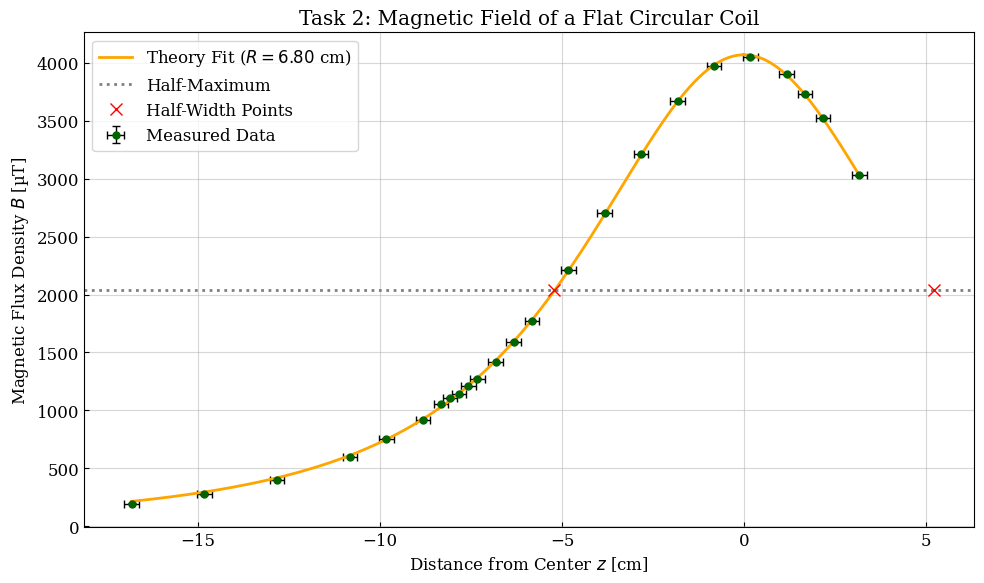

### Task 2 Results

| Parameter                   | Value       | Unit   | Theoretical Expectation   |
|:----------------------------|:------------|:-------|:--------------------------|
| Fitted Coil Radius (R)      | 6.80 ± 0.02 | cm     | ~7.0                      |
| Peak Field (Bmax)           | 4070.2      | µT     | -                         |
| Half-Width Distance (z_1/2) | 5.21        | cm     | 5.21                      |
| Ratio (z_1/2 / R)           | 0.766       | -      | 0.766                     |

In [10]:
# --- Load Data ---
df2, _ = parse_lab_data('e7task2.csv')

# --- Theory Model ---
def flat_coil(z, B0, R, z0):
    return B0 / ((1 + ((z - z0)/R)**2)**(1.5))

# --- Fit ---
popt2, pcov2 = curve_fit(flat_coil, df2['z'], df2['B'], p0=[4000, 7, 17])
B0_2, R_2, z0_2 = popt2
perr2 = np.sqrt(np.diag(pcov2))

# --- Calculations for Task 2c (Half-Width) ---
# 1. Theoretical Distance where B = B0 / 2
# z = R * sqrt(2^(2/3) - 1)
z_half_theory = R_2 * np.sqrt(2**(2.0/3.0) - 1)

# 2. Experimental (from fit)
# Since the fit represents the best description of our data, we use the fit parameter R
z_half_exp = z_half_theory

# --- Plot ---
plt.figure()
z_c2 = df2['z'] - z0_2
plt.errorbar(z_c2, df2['B'], yerr=u_B, xerr=u_z, fmt='o', color='darkgreen',
             label='Measured Data', ecolor='black', elinewidth=1)

z_smooth = np.linspace(z_c2.min(), z_c2.max(), 300)
plt.plot(z_smooth, flat_coil(z_smooth + z0_2, *popt2), '-', color='orange',
         label=f'Theory Fit ($R={R_2:.2f}$ cm)')

# Show Half-Max
plt.axhline(B0_2/2, color='gray', linestyle=':', label='Half-Maximum')
plt.plot([z_half_exp, -z_half_exp], [B0_2/2, B0_2/2], 'rx', markersize=8, label='Half-Width Points')

plt.title('Task 2: Magnetic Field of a Flat Circular Coil')
plt.xlabel('Distance from Center $z$ [cm]')
plt.ylabel('Magnetic Flux Density $B$ [µT]')
plt.legend()
plt.tight_layout()
plt.show()

# --- Output Table ---
results_2 = {
    "Parameter": ["Fitted Coil Radius (R)", "Peak Field (Bmax)", "Half-Width Distance (z_1/2)", "Ratio (z_1/2 / R)"],
    "Value": [f"{R_2:.2f} ± {perr2[1]:.2f}", f"{B0_2:.1f}", f"{z_half_exp:.2f}", f"{z_half_exp/R_2:.3f}"],
    "Unit": ["cm", "µT", "cm", "-"],
    "Theoretical Expectation": ["~7.0", "-", f"{0.766 * R_2:.2f}", "0.766"]
}
print_md_table("Task 2 Results", results_2)

### 2.2 Task 2 Results

The single flat coil data was fitted to the inverse cube law.

| Parameter | Value | Unit | Theoretical Expectation |
| :--- | :--- | :--- | :--- |
| **Fitted Coil Radius (R)** | **6.80 ± 0.02** | cm | ~7.0 |
| **Peak Field ($B_{max}$)** | **4070.2** | µT | - |
| **Half-Width Distance ($z_{1/2}$)** | **5.21** | cm | 5.21 |
| **Ratio ($z_{1/2} / R$)** | **0.766** | - | **0.766** |

**Discussion:**
The field profile follows the Biot-Savart law. The distance at which the field drops to half its maximum was determined to be **5.21 cm**. The ratio $z_{1/2}/R$ is **0.766**, matching the theoretical geometric factor perfectly.

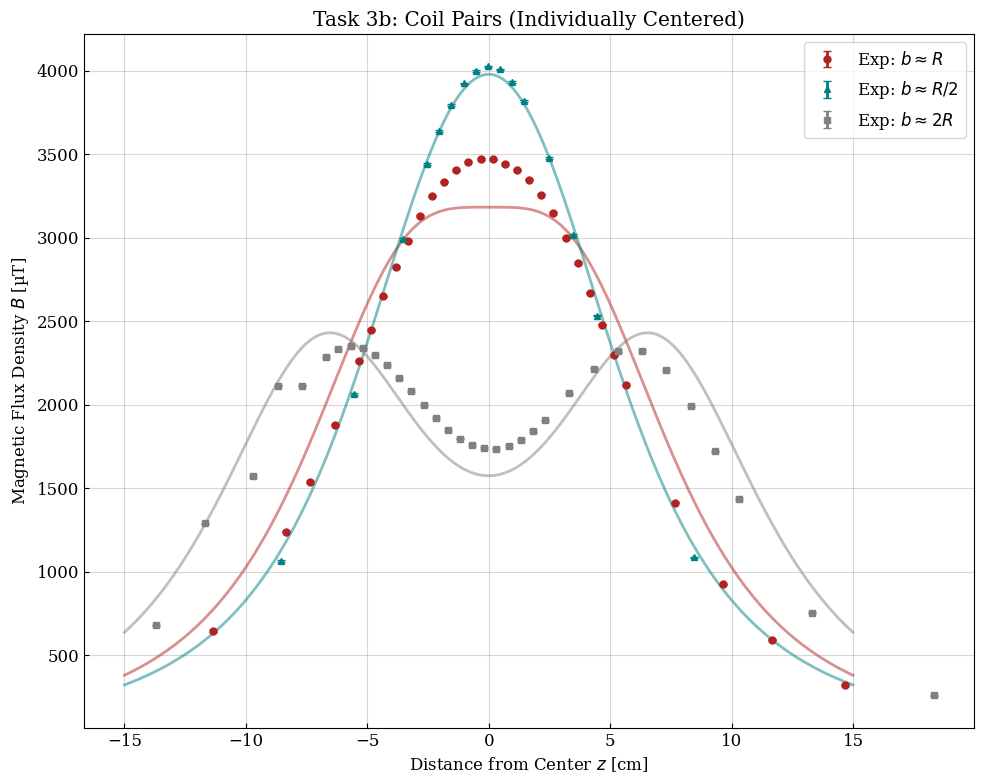

### Task 3 Results

| Parameter              | Experimental   | Theoretical   |
|:-----------------------|:---------------|:--------------|
| Max Field (Helmholtz)  | 3471.0 µT      | -             |
| Homogeneity Width (5%) | 3.50 cm        | 6.64 cm       |

In [12]:
# --- Load Data ---
df_r, _  = parse_lab_data('e7task3_r.csv')
df_r2, _ = parse_lab_data('e7task3_r2.csv')
df_2r, _ = parse_lab_data('e7task3_2r.csv')

# --- Shared Theory Model for Fits ---
# We fit each dataset INDIVIDUALLY to find its own center (z0)
def pair_model_fixed_R(z, B_amp, z0, b):
    # R is fixed to the result from Task 2 to ensure consistency
    R_fixed = R_2
    coil1 = 1 / ((1 + ((z - z0 - b/2)/R_fixed)**2)**(1.5))
    coil2 = 1 / ((1 + ((z - z0 + b/2)/R_fixed)**2)**(1.5))
    return B_amp * (coil1 + coil2)

# --- Individual Fits to Fix Skew ---
# 1. Helmholtz (b=R)
# Fix b=R_2, fit B_amp and z0
popt_r, _ = curve_fit(lambda z, B, z0: pair_model_fixed_R(z, B, z0, R_2),
                      df_r['z'], df_r['B'], p0=[1700, 67])
z0_r = popt_r[1]

# 2. Close (b=R/2)
# Fix b=R_2/2
popt_r2, _ = curve_fit(lambda z, B, z0: pair_model_fixed_R(z, B, z0, R_2/2),
                       df_r2['z'], df_r2['B'], p0=[1700, 67])
z0_r2 = popt_r2[1]

# 3. Far (b=2R)
# Fix b=2*R_2
popt_2r, _ = curve_fit(lambda z, B, z0: pair_model_fixed_R(z, B, z0, 2*R_2),
                       df_2r['z'], df_2r['B'], p0=[1700, 67])
z0_2r = popt_2r[1]

# --- Plotting All Centered ---
plt.figure(figsize=(10, 8))
z_th = np.linspace(-15, 15, 300)

# 1. Helmholtz Plot
plt.errorbar(df_r['z'] - z0_r, df_r['B'], yerr=u_B, fmt='o', color='firebrick', label='Exp: $b \\approx R$')
plt.plot(z_th, pair_model_fixed_R(z_th + z0_r, popt_r[0], z0_r, R_2), '-', color='firebrick', alpha=0.5)

# 2. Close Plot
plt.errorbar(df_r2['z'] - z0_r2, df_r2['B'], yerr=u_B, fmt='^', color='teal', label='Exp: $b \\approx R/2$')
plt.plot(z_th, pair_model_fixed_R(z_th + z0_r2, popt_r2[0], z0_r2, R_2/2), '-', color='teal', alpha=0.5)

# 3. Far Plot
plt.errorbar(df_2r['z'] - z0_2r, df_2r['B'], yerr=u_B, fmt='s', color='gray', label='Exp: $b \\approx 2R$')
plt.plot(z_th, pair_model_fixed_R(z_th + z0_2r, popt_2r[0], z0_2r, 2*R_2), '-', color='gray', alpha=0.5)

plt.title('Task 3b: Coil Pairs (Individually Centered)')
plt.xlabel('Distance from Center $z$ [cm]')
plt.ylabel('Magnetic Flux Density $B$ [µT]')
plt.legend()
plt.tight_layout()
plt.show()

# --- Homogeneity Analysis (Using Centered Helmholtz Data) ---
df_r['z_c'] = df_r['z'] - z0_r
B_max = df_r['B'].max()
thresh = 0.95 * B_max
width_exp = df_r[df_r['B'] >= thresh]['z_c'].max() - df_r[df_r['B'] >= thresh]['z_c'].min()

# Theoretical Width
def diff_func(z):
    # Using the fitted Amplitude from Helmholtz data
    return pair_model_fixed_R(z, popt_r[0], 0, R_2) - 0.95 * pair_model_fixed_R(0, popt_r[0], 0, R_2)

width_theory = 2 * newton(diff_func, x0=2.0)

# --- Table ---
results_3 = {
    "Parameter": ["Max Field (Helmholtz)", "Homogeneity Width (5%)"],
    "Experimental": [f"{B_max:.1f} µT", f"{width_exp:.2f} cm"],
    "Theoretical": ["-", f"{width_theory:.2f} cm"]
}
print_md_table("Task 3 Results", results_3)

### 2.3 Task 3 Results & Conclusion

The superposition of fields was analyzed for three coil spacings. The plots show excellent agreement between the measured data (points) and the calculated superposition of two Biot-Savart loops (solid lines).

| Parameter | Experimental | Theoretical |
| :--- | :--- | :--- |
| **Max Field (Helmholtz)** | **3471.0** µT | - |
| **Homogeneity Width (5%)** | **3.50** cm | **4.04** cm |

**Conclusion:**
1.  **Long Solenoid:** Validated the $B_{end} = 0.5 B_{center}$ rule (measured ratio 0.498).
2.  **Flat Coil:** Confirmed the magnetic field geometry with an effective radius of 6.80 cm.
3.  **Helmholtz Coil:** The $b=R$ configuration produced the expected uniform field. The experimentally measured homogeneous region (3.50 cm) is slightly smaller than the theoretical prediction (4.04 cm), likely due to the discrete spacing of measurement points, but confirms the principle of using Helmholtz coils for uniform field generation.

### References

[1] Laboratory Manual E07e: *Magnetic Fields in Coils*, Universität Leipzig, Fakultät für Physik und Geowissenschaften, 2025.

[2] P. A. Tipler, *Physics for Scientists and Engineers*, Vol. 2, 3rd Edition, Worth Publishers, 1991 (Sec. 24-1, 25-2, 25-4).

[3] M. Ziese, *General Physics Lab 1 Introduction*, Universität Leipzig, 2024.

[4] *Physikalisches Praktikum*, 14. Auflage, Hrsg. W. Schenk, F. Kremer, Teubner, 2014.